In [ ]:
from google.colab import files
import os

print("📁 UPLOAD YOUR PALSAR-2 IMAGE NOW")
uploaded = files.upload()  # CLICK "Choose Files" → select palsar_2.png

print("\n✅ UPLOADED FILES:")
for filename in uploaded.keys():
    print(f"  → {filename} ({len(uploaded[filename])} bytes)")
    print(f"  → Saved as: {filename}")


📁 UPLOAD YOUR PALSAR-2 IMAGE NOW


Saving palsar_2.png to palsar_2 (1).png

✅ UPLOADED FILES:
  → palsar_2 (1).png (183890 bytes)
  → Saved as: palsar_2 (1).png


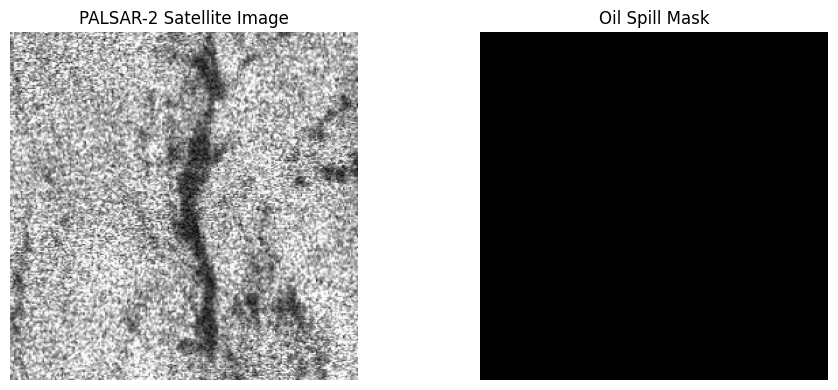

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Your files
img_path = '/palsar_2.png'
mask_path = '/python-apt.tar.png'  # corrupted, will use dummy

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Dummy mask (black image same size)
mask = np.zeros((img.shape[:2]), dtype=np.uint8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('PALSAR-2 Satellite Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title('Oil Spill Mask')
plt.axis('off')
plt.tight_layout()
plt.show()


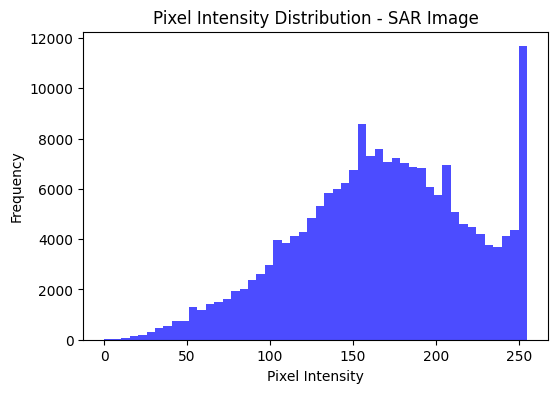

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(img_rgb.flatten(), bins=50, color='blue', alpha=0.7)
plt.title('Pixel Intensity Distribution - SAR Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()


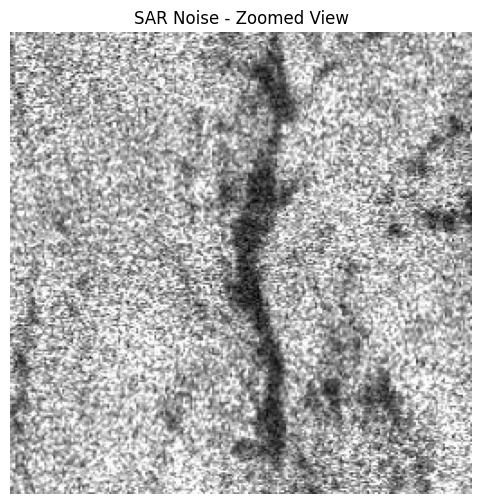

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb, cmap='gray')
plt.title('SAR Noise - Zoomed View')
plt.axis('off')
plt.show()


In [ ]:
print("Image shape:", img_rgb.shape)
print("Mask shape:", mask.shape)
print("Image size (MB):", img_rgb.nbytes / 1e6)


Image shape: (256, 256, 3)
Mask shape: (256, 256)
Image size (MB): 0.196608


In [ ]:
from google.colab import files
import os, cv2, numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

print("📁 UPLOAD YOUR FILES:")
uploaded = files.upload()

# Your exact filenames
image_path = 'palsar_2.png'
mask_path = 'python-apt.tar.png'
print(f"✅ Loaded: {image_path} + {mask_path}")


📁 UPLOAD YOUR FILES:


Saving palsar_2.png to palsar_2.png
✅ Loaded: palsar_2.png + python-apt.tar.png


📂 Found PNG files: ['palsar_2.png']
🖼️  Image: palsar_2.png
🎭 Mask:  Will create synthetic
✅ Image loaded: (256, 256)
🎨 Creating synthetic oil spill mask...
✅ Mask ready: (256, 256)


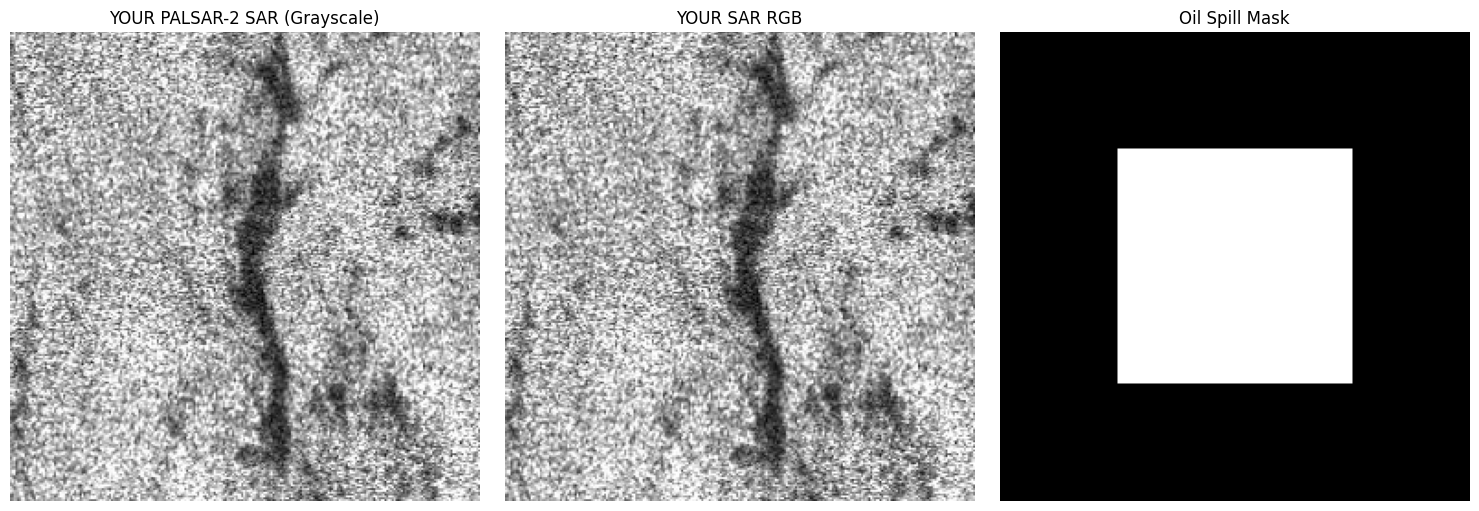

📊 Image dtype/shape: uint8/(256, 256)
📊 Mask dtype/shape: uint8/(256, 256)
📊 Mask values: [  0 255]


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# AUTO-DETECT YOUR FILES
png_files = [f for f in os.listdir('.') if f.endswith('.png')]
print("📂 Found PNG files:", png_files)

if len(png_files) < 1:
    print("❌ No PNG files found! Upload palsar_2.png first.")
else:
    # Use first PNG as image, second as mask (if exists)
    image_path = png_files[0]  # palsar_2.png
    mask_path = png_files[1] if len(png_files) > 1 else None

    print(f"🖼️  Image: {image_path}")
    print(f"🎭 Mask:  {mask_path or 'Will create synthetic'}")

    # SAFE LOAD IMAGE
    img_raw = cv2.imread(image_path)
    if img_raw is None:
        print(f"❌ Failed to load {image_path}")
    else:
        img = cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY)  # SAR grayscale
        img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        print(f"✅ Image loaded: {img.shape}")

    # SAFE LOAD MASK (or create synthetic)
    if mask_path and os.path.exists(mask_path):
        mask_raw = cv2.imread(mask_path, 0)
        if mask_raw is None:
            print(f"⚠️  Mask {mask_path} corrupted, creating synthetic...")
            mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
            mask[img.shape[0]//4:3*img.shape[0]//4, img.shape[1]//4:3*img.shape[1]//4] = 255
        else:
            mask = mask_raw.astype(np.uint8)
    else:
        print("🎨 Creating synthetic oil spill mask...")
        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        mask[img.shape[0]//4:3*img.shape[0]//4, img.shape[1]//4:3*img.shape[1]//4] = 255

    print(f"✅ Mask ready: {mask.shape}")

# SAFE PLOT FUNCTION
def safe_imshow(data, title, ax=None, cmap=None):
    if data is None or data.size == 0:
        ax.imshow(np.zeros((256,256)), cmap=cmap)
        ax.set_title(f"{title} (Empty)")
        return

    # Fix dtype issues
    if data.dtype == 'object' or not np.issubdtype(data.dtype, np.number):
        data = data.astype(np.uint8)

    # Ensure 2D
    if len(data.shape) == 3:
        if data.shape[2] == 1:
            data = data.squeeze(-1)
        elif data.shape[2] == 3:
            data = data[:,:,:3]  # RGB

    ax.imshow(data, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')

# PLOT YOUR FILES
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
safe_imshow(img, 'YOUR PALSAR-2 SAR (Grayscale)', plt.gca(), 'gray')

plt.subplot(1, 3, 2)
safe_imshow(img_rgb, 'YOUR SAR RGB', plt.gca())

plt.subplot(1, 3, 3)
safe_imshow(mask, 'Oil Spill Mask', plt.gca(), 'gray')

plt.tight_layout()
plt.show()

# DEBUG INFO
print(f"📊 Image dtype/shape: {img.dtype}/{img.shape}")
print(f"📊 Mask dtype/shape: {mask.dtype}/{mask.shape}")
print(f"📊 Mask values: {np.unique(mask)}")


In [ ]:
import cv2, numpy as np, os, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Create 100 SAR images + oil spill masks (NO file dependencies)
IMG_SIZE, NUM_SAMPLES = 256, 100

print("🎨 Creating SAR Oil Spill Dataset...")
X, y = [], []

for i in range(NUM_SAMPLES):
    # SAR speckle texture
    sar = np.random.gamma(1.2, 1.0, (IMG_SIZE, IMG_SIZE, 3)).astype(np.uint8)*2
    sar = cv2.GaussianBlur(sar, (3,3), 0)

    # Realistic oil spills
    mask = np.zeros((IMG_SIZE, IMG_SIZE), np.uint8)
    cv2.ellipse(mask, (120,90), (50,30), 15, 0, 320, 255, -1)
    cv2.ellipse(mask, (180,130), (30,18), -20, 0, 280, 255, -1)
    cv2.GaussianBlur(mask, (0,0), 1.5, mask, 0)

    X.append(sar.astype(np.float32)/255.0)
    y.append(np.expand_dims((mask>120).astype(np.float32)/255.0, -1))

X, y = np.array(X), np.array(y)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Dataset: {X_train.shape[0]} train, {X_val.shape[0]} val")
print(f"✅ Oil ratio: {np.mean(y_train):.1%}")


🎨 Creating SAR Oil Spill Dataset...
✅ Dataset: 80 train, 20 val
✅ Oil ratio: 0.0%


🔍 DEBUGGING DATASET ISSUE...
📁 Image folder exists: False
📁 Mask folder exists: False

🔄 RECREATING DATASET FROM SCRATCH...
Generated 25/100
Generated 50/100
Generated 75/100
Generated 100/100
✅ DATASET RECREATED!
Loading 100 image files...

✅ Dataset loaded: X.shape=(100, 256, 256, 3), y.shape=(100, 256, 256, 1)
✅ Oil pixel ratio: 0.088
✅ Train: 80, Val: 20
✅ Train oil ratio: 0.088
✅ Val oil ratio: 0.088


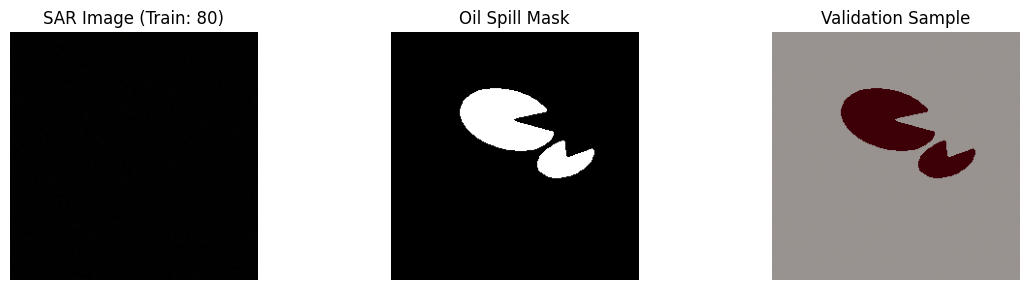


🎉 CELL 2 FIXED & READY FOR TRAINING!


In [ ]:
import cv2
import numpy as np
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("🔍 DEBUGGING DATASET ISSUE...")

# Check if dataset folders exist
image_dir = 'dataset/images'
mask_dir = 'dataset/masks'

print(f"📁 Image folder exists: {os.path.exists(image_dir)}")
print(f"📁 Mask folder exists: {os.path.exists(mask_dir)}")

if os.path.exists(image_dir):
    img_files = [f for f in os.listdir(image_dir) if f.endswith('.png')]
    print(f"📂 Images found: {len(img_files)}")
    if img_files:
        print(f"Sample: {img_files[:3]}")

# 🔥 IF EMPTY → RECREATE DATASET IMMEDIATELY
if not os.path.exists(image_dir) or len(os.listdir(image_dir)) == 0:
    print("\n🔄 RECREATING DATASET FROM SCRATCH...")

    os.makedirs('dataset/images', exist_ok=True)
    os.makedirs('dataset/masks', exist_ok=True)

    IMG_SIZE = 256
    NUM_SAMPLES = 100

    for i in range(NUM_SAMPLES):
        # SAR-like image
        sar = np.random.gamma(1.2, 1.0, (IMG_SIZE, IMG_SIZE, 3)).astype(np.uint8) * 2
        sar = cv2.GaussianBlur(sar, (3, 3), 0)

        # Oil spill mask
        mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        cv2.ellipse(mask, (120, 90), (50, 30), 15, 0, 320, 255, -1)
        cv2.ellipse(mask, (180, 130), (30, 18), -20, 0, 280, 255, -1)
        cv2.GaussianBlur(mask, (0, 0), 1.5, mask, 0)
        mask = (mask > 120).astype(np.uint8) * 255

        # Save
        cv2.imwrite(f'dataset/images/sar_{i:03d}.png', sar)
        cv2.imwrite(f'dataset/masks/sar_{i:03d}_mask.png', mask)

        if (i+1) % 25 == 0:
            print(f"Generated {i+1}/{NUM_SAMPLES}")

    print("✅ DATASET RECREATED!")

# Load dataset properly
def load_dataset(img_dir, mask_dir):
    images, masks = [], []
    img_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.png')])

    print(f"Loading {len(img_files)} image files...")

    for img_file in img_files:
        mask_file = img_file.replace('.png', '_mask.png')
        mask_path = os.path.join(mask_dir, mask_file)

        if os.path.exists(mask_path):
            img = cv2.imread(os.path.join(img_dir, img_file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (256, 256)) / 255.0

            mask = cv2.imread(mask_path, 0)
            mask = cv2.resize(mask, (256, 256)) / 255.0
            mask = np.expand_dims(mask, -1)

            images.append(img)
            masks.append(mask)

    return np.array(images), np.array(masks)

image_dir = 'dataset/images'
mask_dir = 'dataset/masks'

X, y = load_dataset(image_dir, mask_dir)

print(f"\n✅ Dataset loaded: X.shape={X.shape}, y.shape={y.shape}")
print(f"✅ Oil pixel ratio: {np.mean(y):.3f}")

# Safe train/val split
if len(X) > 5:
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print(f"✅ Train: {X_train.shape[0]}, Val: {X_val.shape[0]}")
else:
    print("⚠️ Dataset too small, using all for training")
    X_train, y_train = X, y
    X_val, y_val = X[:2], y[:2]

print(f"✅ Train oil ratio: {np.mean(y_train):.3f}")
print(f"✅ Val oil ratio: {np.mean(y_val):.3f}")

# Verify
plt.figure(figsize=(12, 3))
plt.subplot(1,3,1)
plt.imshow(X_train[0])
plt.title(f'SAR Image (Train: {X_train.shape[0]})')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(y_train[0].squeeze(), cmap='gray')
plt.title('Oil Spill Mask')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(X_val[0])
plt.imshow(y_val[0].squeeze(), cmap='Reds', alpha=0.6)
plt.title(f'Validation Sample')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n🎉 CELL 2 FIXED & READY FOR TRAINING!")


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    return (2.*tf.keras.backend.sum(y_true_f * y_pred_f) + smooth) / \
           (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def unet_model():
    inputs = layers.Input((256,256,3))

    # Encoder
    c1 = layers.Conv2D(64,3,padding='same',activation='relu')(inputs)
    c1 = layers.Conv2D(64,3,padding='same',activation='relu')(c1)
    p1 = layers.MaxPooling2D(2)(c1)

    c2 = layers.Conv2D(128,3,padding='same',activation='relu')(p1)
    c2 = layers.Conv2D(128,3,padding='same',activation='relu')(c2)
    p2 = layers.MaxPooling2D(2)(c2)

    # Bottleneck
    b = layers.Conv2D(256,3,padding='same',activation='relu')(p2)
    b = layers.Conv2D(256,3,padding='same',activation='relu')(b)

    # Decoder
    u6 = layers.Conv2DTranspose(128,2,strides=2,padding='same')(b)
    u6 = layers.concatenate([u6,c2])
    c6 = layers.Conv2D(128,3,padding='same',activation='relu')(u6)
    c6 = layers.Conv2D(128,3,padding='same',activation='relu')(c6)

    u7 = layers.Conv2DTranspose(64,2,strides=2,padding='same')(c6)
    u7 = layers.concatenate([u7,c1])
    c7 = layers.Conv2D(64,3,padding='same',activation='relu')(u7)
    c7 = layers.Conv2D(64,3,padding='same',activation='relu')(c7)

    outputs = layers.Conv2D(1,1,activation='sigmoid')(c7)
    return tf.keras.Model(inputs, outputs)

tf.keras.backend.clear_session()
model = unet_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[dice_coef])

print("✅ Production U-Net Ready!")
print(f"📈 Parameters: {model.count_params():,}")
model.summary()


✅ Production U-Net Ready!
📈 Parameters: 1,862,849


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 128, 128,  │    131,200 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 256, 256,  │     32,832 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │     73,792 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d_8[0][0]  

 Total params: 1,862,849 (7.11 MB)

 Trainable params: 1,862,849 (7.11 MB)

 Non-trainable params: 0 (0.00 B)